In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.ensemble import IsolationForest

In [3]:
df = pd.read_csv("upi_transactions.csv")

In [4]:
df.head()

,Amount,BankNameReceived,BankNameSent,City,Currency,CustomerAccountNumber,CustomerAge,DeviceType,Gender,MerchantAccountNumber,MerchantName,PaymentMethod,PaymentMode,Purpose,RemainingBalance,Status,TransactionDate,TransactionID,TransactionTime,TransactionType
0,348.99,IDFC FIRST Bank,ICICI Bank,Ahmedabad,INR,CUST93774863057,30,POS Device,Male,MERC9703905715,MakeMyTrip,Mobile Number,P2M,Food,109751.36,Success,2025-02-22,UPI20250222000001,18:57:34,Debit
1,287.89,Kotak Mahindra Bank,Canara Bank,Indore,INR,CUST84987658854,23,Web,Female,MERC9256195745,Swiggy,Mobile Number,P2M,Food,172346.02,Success,2025-03-21,UPI20250321000002,11:48:21,Debit
2,827.77,HDFC Bank,Kotak Mahindra Bank,Ahmedabad,INR,CUST47238118820,58,iOS,Female,MERC9896606039,Local Kirana,QR Scan,P2M,Grocery,177452.31,Success,2025-04-30,UPI20250430000003,20:24:17,Debit
3,3695.29,Yes Bank,Axis Bank,Patna,INR,CUST56033091279,49,POS Device,Female,CUST96812569967,Individual Transfer,Bank Account,P2P,Rent,285232.70,Pending,2025-06-16,UPI20250616000004,20:49:03,Debit
4,614.42,IDFC FIRST Bank,Kotak Mahindra Bank,Patna,INR,CUST27650808629,68,POS Device,Female,CUST34169696708,Individual Transfer,Bank Account,P2P,Family Support,23896.65,Success,2025-10-27,UPI20251027000005,14:37:25,Debit


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Amount                 20000 non-null  float64
 1   BankNameReceived       20000 non-null  object 
 2   BankNameSent           20000 non-null  object 
 3   City                   20000 non-null  object 
 4   Currency               20000 non-null  object 
 5   CustomerAccountNumber  20000 non-null  object 
 6   CustomerAge            20000 non-null  int64  
 7   DeviceType             20000 non-null  object 
 8   Gender                 20000 non-null  object 
 9   MerchantAccountNumber  20000 non-null  object 
 10  MerchantName           20000 non-null  object 
 11  PaymentMethod          20000 non-null  object 
 12  PaymentMode            20000 non-null  object 
 13  Purpose                20000 non-null  object 
 14  RemainingBalance       20000 non-null  float64
 15  St

In [6]:
df.columns = df.columns.str.strip()

In [7]:
# Check columns
print(df.columns)
print(df.head())

Index(['Amount', 'BankNameReceived', 'BankNameSent', 'City', 'Currency',
       'CustomerAccountNumber', 'CustomerAge', 'DeviceType', 'Gender',
       'MerchantAccountNumber', 'MerchantName', 'PaymentMethod', 'PaymentMode',
       'Purpose', 'RemainingBalance', 'Status', 'TransactionDate',
       'TransactionID', 'TransactionTime', 'TransactionType'],
      dtype='object')
    Amount     BankNameReceived         BankNameSent       City Currency  \
0   348.99      IDFC FIRST Bank           ICICI Bank  Ahmedabad      INR   
1   287.89  Kotak Mahindra Bank          Canara Bank     Indore      INR   
2   827.77            HDFC Bank  Kotak Mahindra Bank  Ahmedabad      INR   
3  3695.29             Yes Bank            Axis Bank      Patna      INR   
4   614.42      IDFC FIRST Bank  Kotak Mahindra Bank      Patna      INR   

  CustomerAccountNumber  CustomerAge  DeviceType  Gender  \
0       CUST93774863057           30  POS Device    Male   
1       CUST84987658854           23         We

In [8]:
# Convert numeric columns properly
numeric_cols = ["Amount", "CustomerAge", "RemainingBalance"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
# Remove rows where numeric values are missing
df = df.dropna(subset=numeric_cols)


In [10]:
# Select features
features = df[numeric_cols]

In [11]:
#Build Model

In [12]:
model = IsolationForest(contamination=0.02, random_state=42)

In [13]:
#Predict Anomalies

df['Anomaly'] = model.fit_predict(features)

In [14]:
df['FraudFlag'] = df['Anomaly'].map({
    1: "Normaly",
    -1: "Suspicious"
})

In [15]:
# Save output
df.to_csv("upi_fraud_output.csv", index=False)

print("Fraud detection completed successfully")

In [16]:
print(df[["Amount", "CustomerAge", "RemainingBalance"]].head(10))
print(df[["Amount", "CustomerAge", "RemainingBalance"]].dtypes)

    Amount  CustomerAge  RemainingBalance
0   348.99           30         109751.36
1   287.89           23         172346.02
2   827.77           58         177452.31
3  3695.29           49         285232.70
4   614.42           68          23896.65
5   268.41           50          80189.13
6   134.62           33         492540.75
7   338.44           46         270447.19
8   198.13           48         334621.78
9   449.99           46         430524.61
Amount              float64
CustomerAge           int64
RemainingBalance    float64
dtype: object


In [17]:
print(df["FraudFlag"].value_counts())

FraudFlag
Normaly       19600
Suspicious      400
Name: count, dtype: int64


In [18]:
frauds = df[df["FraudFlag"] == "Suspicious"]

print(frauds.head())

       Amount BankNameReceived     BankNameSent     City Currency  \
160  15843.93      Canara Bank         Yes Bank  Kolkata      INR   
304  14821.51    IndusInd Bank  IDFC FIRST Bank   Jaipur      INR   
317  17575.69         Yes Bank  IDFC FIRST Bank   Mumbai      INR   
320  69208.20        HDFC Bank        Axis Bank  Lucknow      INR   
337  29979.25  IDFC FIRST Bank    IndusInd Bank    Noida      INR   

    CustomerAccountNumber  CustomerAge  DeviceType  Gender  \
160       CUST51169712660           21     Android    Male   
304       CUST78665889299           27  POS Device    Male   
317       CUST43788305570           42     Android  Female   
320       CUST15019768628           45         Web    Male   
337       CUST35102070723           36     Android  Female   

    MerchantAccountNumber  ... PaymentMode          Purpose RemainingBalance  \
160       CUST74930377009  ...         P2P   Loan Repayment        180015.14   
304       CUST46556246979  ...         P2P   Loan Re

In [19]:
frauds[
[
"TransactionID",
"Amount",
"CustomerAge",
"RemainingBalance",
"FraudFlag"
]
]

,TransactionID,Amount,CustomerAge,RemainingBalance,FraudFlag
160,UPI20251202000161,15843.93,21,180015.14,Suspicious
304,UPI20251031000305,14821.51,27,460991.90,Suspicious
317,UPI20250503000318,17575.69,42,94120.88,Suspicious
320,UPI20250801000321,69208.20,45,85491.63,Suspicious
337,UPI20251203000338,29979.25,36,374144.07,Suspicious
...,...,...,...,...,...
19673,UPI20250420019674,29971.94,29,25933.90,Suspicious
19778,UPI20250130019779,28872.46,52,343917.87,Suspicious
19789,UPI20250728019790,16855.34,67,445172.94,Suspicious
19934,UPI20250629019935,11596.23,69,19778.29,Suspicious


In [20]:
frauds.to_csv(
    "fraud_transactions.csv",
    index=False
)

In [21]:
customer_df = df.groupby(
    "CustomerAccountNumber"
).agg(
    TotalAmount=("Amount","sum"),
    AvgAmount=("Amount","mean"),
    TransactionCount=("TransactionID","count"),
    AvgBalance=("RemainingBalance","mean")
)

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [23]:
customer_df.head()

,TotalAmount,AvgAmount,TransactionCount,AvgBalance
CustomerAccountNumber,,,,
CUST10000311359,749.31,749.31,1,367692.56
CUST10001035414,140.32,140.32,1,250125.92
CUST10003181749,1140.51,1140.51,1,444927.74
CUST10008125098,1041.07,1041.07,1,344391.83
CUST10009880661,10666.30,10666.30,1,88878.89


In [25]:
features = customer_df[["TotalAmount", "AvgAmount", "TransactionCount", "AvgBalance" ]]

In [27]:
features.head()

,TotalAmount,AvgAmount,TransactionCount,AvgBalance
CustomerAccountNumber,,,,
CUST10000311359,749.31,749.31,1,367692.56
CUST10001035414,140.32,140.32,1,250125.92
CUST10003181749,1140.51,1140.51,1,444927.74
CUST10008125098,1041.07,1041.07,1,344391.83
CUST10009880661,10666.30,10666.30,1,88878.89


In [28]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [30]:
import matplotlib.pyplot as plt

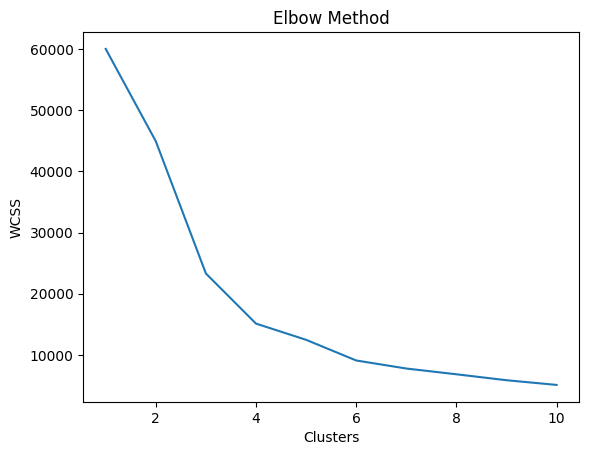

In [31]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [32]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

customer_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [33]:
customer_df.head()

,TotalAmount,AvgAmount,TransactionCount,AvgBalance,Cluster
CustomerAccountNumber,,,,,
CUST10000311359,749.31,749.31,1,367692.56,0
CUST10001035414,140.32,140.32,1,250125.92,0
CUST10003181749,1140.51,1140.51,1,444927.74,0
CUST10008125098,1041.07,1041.07,1,344391.83,0
CUST10009880661,10666.30,10666.30,1,88878.89,3


In [42]:
customer_df["CustomerSegment"] = customer_df[
    "Cluster"
    ].map({
        0:"Premium Users",
        1:"Regular Users",
        2:"Low Value Users",
        3:"High Frequency Users"
    })

SyntaxError: unterminated string literal (detected at line 1) (2667455196.py, line 1)

In [40]:
customer_df.groupby("CustomerSegment")[["TotalAmount","TransactionCount","AvgBalance"]
].mean()

,TotalAmount,TransactionCount,AvgBalance
CustomerSegment,,,
High Frequency Users,14999.224196,1.0,258113.747239
Low Value Users,62350.909333,1.0,230547.998167
Premium Users,1251.148839,1.0,374304.897057
Regular Users,1271.495427,1.0,124802.919110


In [43]:
customer_df = df.groupby(
    "CustomerAccountNumber"
).agg(
    TotalAmount=("Amount", "sum"),
    AvgAmount=("Amount", "mean"),
    TransactionCount=("TransactionID", "count"),
    AvgBalance=("RemainingBalance", "mean")
).reset_index()

In [44]:
customer_df.head()

,CustomerAccountNumber,TotalAmount,AvgAmount,TransactionCount,AvgBalance
0,CUST10000311359,749.31,749.31,1,367692.56
1,CUST10001035414,140.32,140.32,1,250125.92
2,CUST10003181749,1140.51,1140.51,1,444927.74
3,CUST10008125098,1041.07,1041.07,1,344391.83
4,CUST10009880661,10666.30,10666.30,1,88878.89


In [45]:
customer_df.to_csv("customer_segments.csv",index=False)